# Lab Exercise 1: Exploratory Data Analysis (EDA)
## Dataset: Patient Length of Stay Prediction

This notebook is designed to satisfy all requirements mentioned in the lab sheet:

### Part A: Dataset Understanding
- Domain identification
- Number of records and attributes
- Feature types
- Target variable
- Dataset significance

### Part B: Data Quality Assessment
- Missing values
- Duplicate records
- Invalid/inconsistent values
- Data reliability

### Part C: Feature Analysis
- Feature categorization
- Correlation analysis
- Feature importance
- Redundant features
- Feature engineering suggestions

### Part D: Insight Generation
- Trends and patterns
- Relationships among variables
- Business/domain implications
- ML recommendations


In [ ]:
# Install packages if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style('whitegrid')


## Upload Dataset

In [ ]:
from google.colab import files
import io # Import io module for in-memory file handling

uploaded = files.upload()

filename = list(uploaded.keys())[0]
# Read the content directly from the uploaded bytes object using io.StringIO
# This ensures correct parsing bypassing potential path issues or re-encoding.
df = pd.read_csv(io.StringIO(uploaded[filename].decode('utf-8')), sep=',')

df.head()

Saving LengthOfStay[1].csv to LengthOfStay[1] (2).csv


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


## Part A - Dataset Understanding

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Shape: (100000, 28)

Columns:
['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay']

Data Types:
eid                             int64
vdate                          object
rcount                         object
gender                         object
dialysisrenalendstage           int64
asthma                          int64
irondef                         int64
pneum                           int64
substancedependence             int64
psychologicaldisordermajor      int64
depress                         int64
psychother                      int64
fibrosisandother                int64
malnutrition                    int64
hemo                          

In [ ]:
# Target variable
target = 'lengthofstay'
print("Target Variable:", target)


Target Variable: lengthofstay


### Domain
Healthcare / Hospital Management

### Dataset Purpose
Predict patient hospital stay duration (Length of Stay) using patient demographics,
medical conditions, laboratory measurements, and admission-related information.


## Part B - Data Quality Assessment

In [ ]:
# Missing Values
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)


,0


In [ ]:
# Duplicate Records
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)


Duplicate Records: 0


In [ ]:
# Summary Statistics
df.describe(include='all')


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
count,100000.000000,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000,100000.00000
unique,NaN,367,6,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,378,5,NaN
top,NaN,10/3/2012,0,F,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2/16/2012,E,NaN
freq,NaN,333,55031,57643,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,316,30755,NaN
mean,50000.500000,NaN,NaN,NaN,0.036420,0.035270,0.094940,0.039450,0.063060,0.239040,...,141.963384,14.097185,1.099350,29.805759,73.444720,6.493768,2.123310,NaN,NaN,4.00103
std,28867.657797,NaN,NaN,NaN,0.187334,0.184462,0.293134,0.194664,0.243072,0.426499,...,29.992996,12.952454,0.200262,2.003769,11.644555,0.568473,2.050641,NaN,NaN,2.36031
min,1.000000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000,NaN,NaN,1.00000
25%,25000.750000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,121.682383,11.000000,0.964720,28.454235,66.000000,6.500000,1.000000,NaN,NaN,2.00000
50%,50000.500000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,142.088545,12.000000,1.098764,29.807516,73.000000,6.500000,1.000000,NaN,NaN,4.00000
75%,75000.250000,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,162.180996,14.000000,1.234867,31.156885,81.000000,6.500000,3.000000,NaN,NaN,6.00000


In [ ]:
# Check invalid values in binary columns
binary_cols = [col for col in df.columns if df[col].nunique() <= 2]

for col in binary_cols:
    print(col, sorted(df[col].dropna().unique()))


gender ['F', 'M']
dialysisrenalendstage [np.int64(0), np.int64(1)]
asthma [np.int64(0), np.int64(1)]
irondef [np.int64(0), np.int64(1)]
pneum [np.int64(0), np.int64(1)]
substancedependence [np.int64(0), np.int64(1)]
psychologicaldisordermajor [np.int64(0), np.int64(1)]
depress [np.int64(0), np.int64(1)]
psychother [np.int64(0), np.int64(1)]
fibrosisandother [np.int64(0), np.int64(1)]
malnutrition [np.int64(0), np.int64(1)]
hemo [np.int64(0), np.int64(1)]


### Suggested Data Cleaning
- Remove duplicate records.
- Handle missing values using median/mode imputation.
- Convert date columns to datetime.
- Validate binary columns (0/1).
- Standardize categorical values.


## Part C - Feature Analysis

In [ ]:
# Identify columns that should be numeric (excluding date and problematic string columns)
numeric_cols_to_convert = [
    'eid', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum',
    'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother',
    'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils',
    'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse',
    'respiration', 'secondarydiagnosisnonicd9', 'lengthofstay'
]

# Convert problematic 'rcount' column: replace '5+' with 5, then convert to numeric
df['rcount'] = df['rcount'].astype(str).str.replace('+', '', regex=False).replace('', np.nan)
df['rcount'] = pd.to_numeric(df['rcount'], errors='coerce')

# Convert other identified columns to numeric, coercing errors
for col in numeric_cols_to_convert:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Separate numeric columns (now that types are correct)
numeric_df = df.select_dtypes(include=np.number)

numeric_df.head()

,eid,rcount,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,...,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
0,1,0,0,0,0,0,0,0,0,0,...,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,3
1,2,5,0,0,0,0,0,0,0,0,...,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,7
2,3,1,0,0,0,0,0,0,0,0,...,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,3
3,4,0,0,0,0,0,0,0,0,0,...,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,1
4,5,0,0,0,0,1,0,1,0,0,...,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,4


In [ ]:
# Correlation with target
corr_target = numeric_df.corr()[target].sort_values(ascending=False)
corr_target


,lengthofstay
lengthofstay,1.000000
rcount,0.749514
psychologicaldisordermajor,0.286724
hemo,0.217696
irondef,0.193838
psychother,0.191695
malnutrition,0.174397
dialysisrenalendstage,0.169695
bloodureanitro,0.148290
substancedependence,0.147886


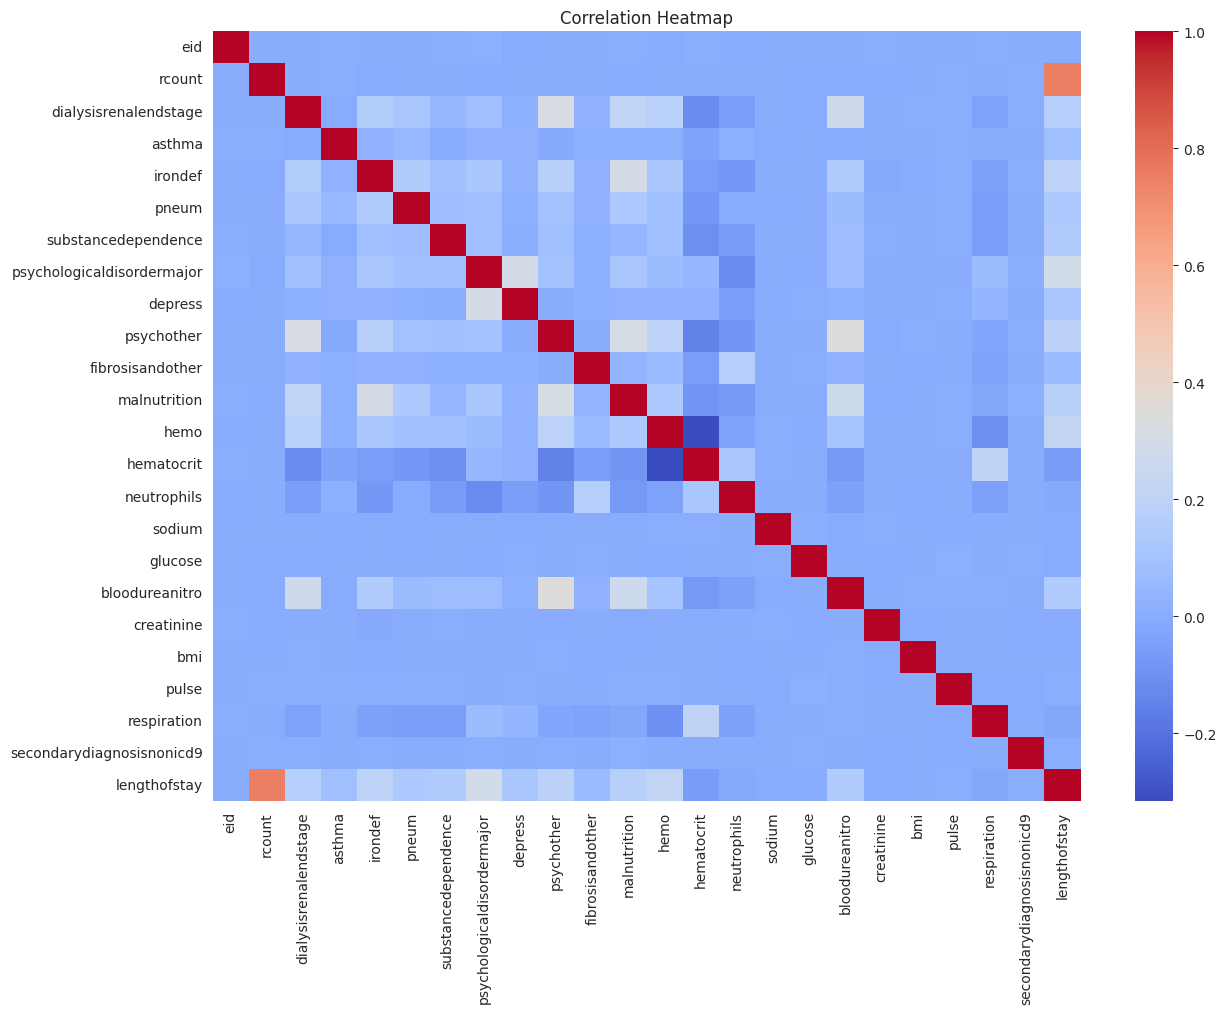

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


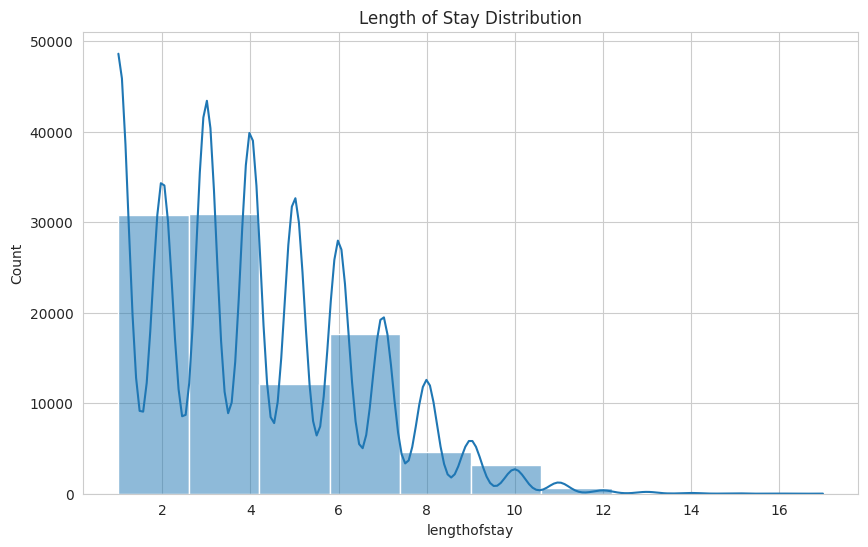

In [ ]:
# Target Distribution
sns.histplot(df[target], bins=10, kde=True)
plt.title('Length of Stay Distribution')
plt.show()


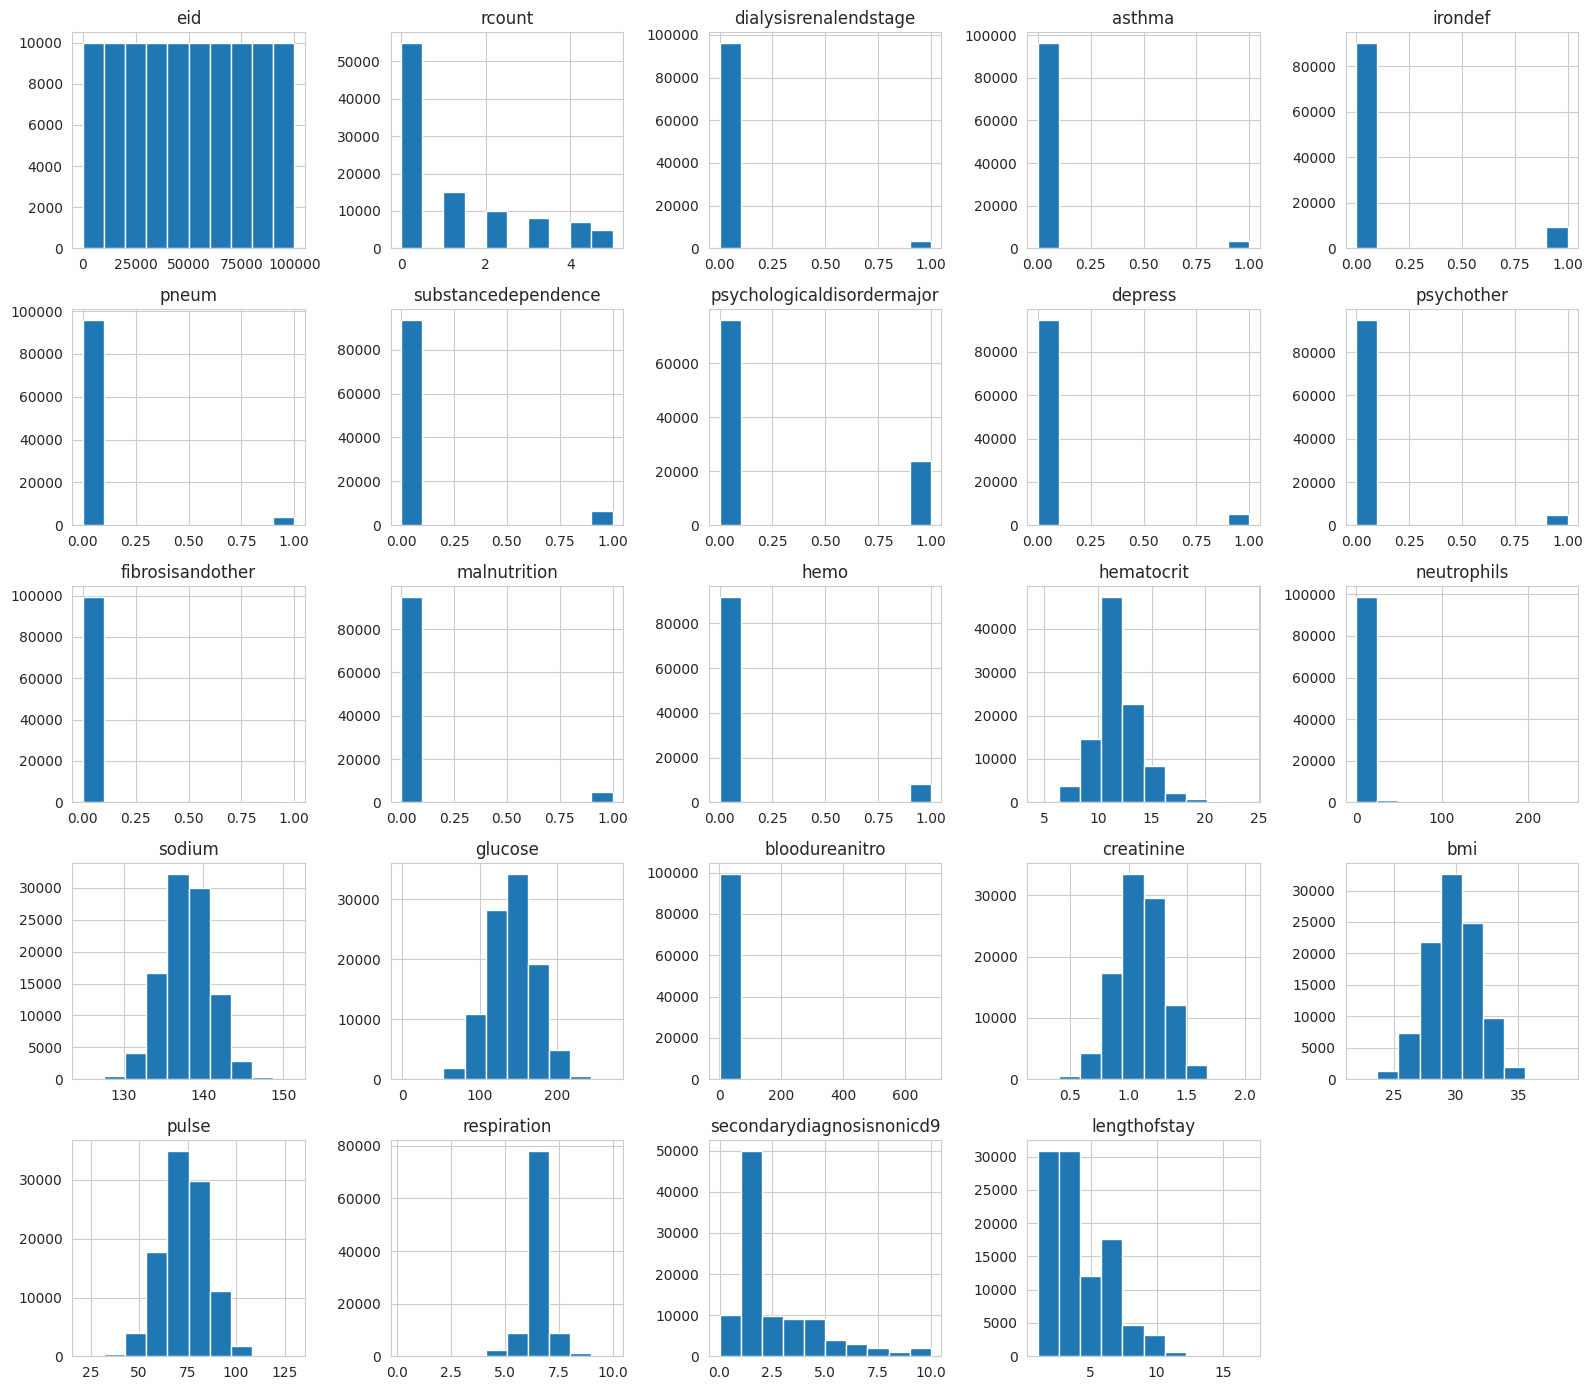

In [ ]:
# Numerical Feature Distributions
numeric_df.hist(figsize=(16,14))
plt.tight_layout()
plt.show()


In [ ]:
# Feature Importance using Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

data = df.copy()

for col in data.select_dtypes(include='object').columns:
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

X = data.drop(columns=[target])
y = data[target]

model = RandomForestRegressor(random_state=42)
model.fit(X, y)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

importance.head(15)


,Feature,Importance
2,rcount,0.564830
26,facid,0.151887
15,hematocrit,0.044455
23,respiration,0.028308
21,bmi,0.025465
20,creatinine,0.024935
18,glucose,0.024581
17,sodium,0.024073
22,pulse,0.022685
14,hemo,0.021484


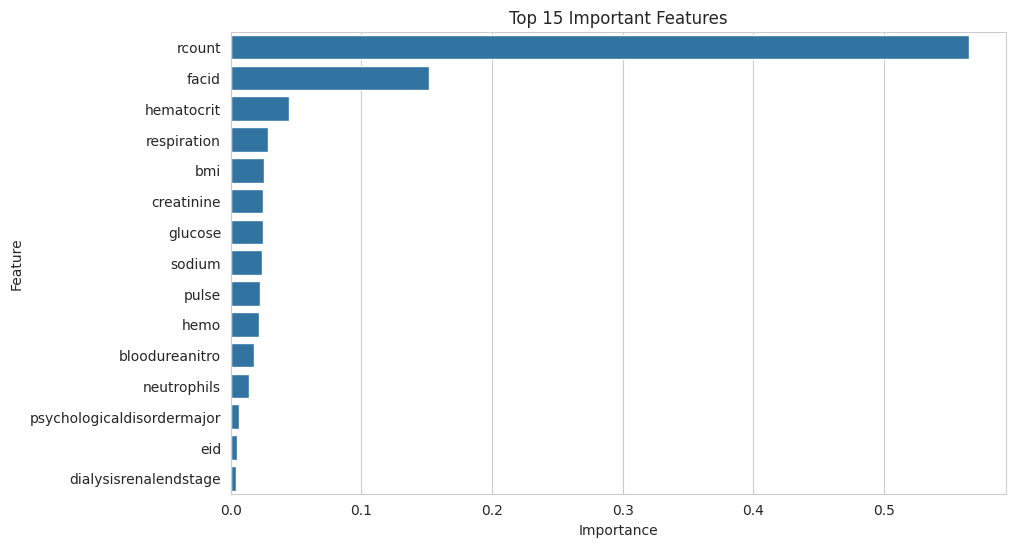

In [ ]:
# Top Features Plot
top15 = importance.head(15)

sns.barplot(data=top15, x='Importance', y='Feature')
plt.title('Top 15 Important Features')
plt.show()


### Feature Categorization

**Numerical Features**
- hemo
- hematocrit
- neutrophils
- sodium
- glucose
- bloodureanitro
- creatinine
- bmi
- pulse
- respiration
- lengthofstay

**Categorical Features**
- gender
- rcount
- facid

**Binary Features**
- dialysisrenalendstage
- asthma
- irondef
- pneum
- substancedependence
- psychologicaldisordermajor
- depress
- psychother
- fibrosisandother
- malnutrition

**Date Features**
- vdate
- discharged


## Part D - Insight Generation

In [ ]:
print('Average Length of Stay:', round(df['lengthofstay'].mean(),2))
print('Median Length of Stay:', round(df['lengthofstay'].median(),2))


Average Length of Stay: 4.0
Median Length of Stay: 4.0


### Report Template

#### Key Findings
1. Dataset belongs to healthcare/hospital management.
2. Target variable is Length of Stay.
3. Laboratory measurements and diagnosis-related variables influence LOS.
4. Correlation and feature importance identify influential predictors.
5. Data quality assessment highlights missing values and duplicates.

#### Trends and Patterns
- Longer stays may be associated with severe conditions.
- Certain laboratory values may correlate with LOS.
- Readmission count and comorbidities may affect hospitalization duration.

#### Domain Implications
- Better resource allocation.
- Bed occupancy forecasting.
- Early risk identification.
- Improved discharge planning.

#### Recommended ML Tasks
1. Length of Stay Prediction (Regression)
2. Stay Category Prediction (Classification)
3. Readmission Risk Prediction
4. Patient Risk Stratification


Saving LengthOfStay.csv.zip to LengthOfStay.csv.zip
Dataset Loaded Successfully!

First 5 Rows


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,...,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,...,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,...,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,...,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,...,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,...,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4



Shape of Dataset
(100000, 28)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   eid                         100000 non-null  int64  
 1   vdate                       100000 non-null  object 
 2   rcount                      100000 non-null  object 
 3   gender                      100000 non-null  object 
 4   dialysisrenalendstage       100000 non-null  int64  
 5   asthma                      100000 non-null  int64  
 6   irondef                     100000 non-null  int64  
 7   pneum                       100000 non-null  int64  
 8   substancedependence         100000 non-null  int64  
 9   psychologicaldisordermajor  100000 non-null  int64  
 10  depress                     100000 non-null  int64  
 11  psychother                  100000 non-null  int64  
 12  fibrosisandother     

,eid,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,...,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,lengthofstay
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000
mean,50000.500000,0.036420,0.035270,0.094940,0.039450,0.063060,0.239040,0.051660,0.049390,0.004790,...,10.177455,137.891397,141.963384,14.097185,1.099350,29.805759,73.444720,6.493768,2.123310,4.00103
std,28867.657797,0.187334,0.184462,0.293134,0.194664,0.243072,0.426499,0.221341,0.216682,0.069044,...,5.353131,2.999669,29.992996,12.952454,0.200262,2.003769,11.644555,0.568473,2.050641,2.36031
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.100000,124.912632,-1.005927,1.000000,0.219770,21.992683,21.000000,0.200000,0.000000,1.00000
25%,25000.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,7.700000,135.871062,121.682383,11.000000,0.964720,28.454235,66.000000,6.500000,1.000000,2.00000
50%,50000.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9.400000,137.887151,142.088545,12.000000,1.098764,29.807516,73.000000,6.500000,1.000000,4.00000
75%,75000.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,11.500000,139.912885,162.180996,14.000000,1.234867,31.156885,81.000000,6.500000,3.000000,6.00000
max,100000.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,245.900000,151.387283,271.444277,682.500000,2.035202,38.935293,130.000000,10.000000,10.000000,17.00000



Column Names
['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay']

Numerical Columns:
['eid', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'lengthofstay']

Categorical Columns:
['vdate', 'rcount', 'gender', 'discharged', 'facid']

Missing Values


,0
eid,0
vdate,0
rcount,0
gender,0
dialysisrenalendstage,0
asthma,0
irondef,0
pneum,0
substancedependence,0
psychologicaldisordermajor,0



Duplicate Records: 0


/tmp/ipykernel_863/1724978520.py:76: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Shape after removing duplicates: (100000, 28)

Original Feature Values


,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration
0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5
1,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5
2,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5
3,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5
4,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6


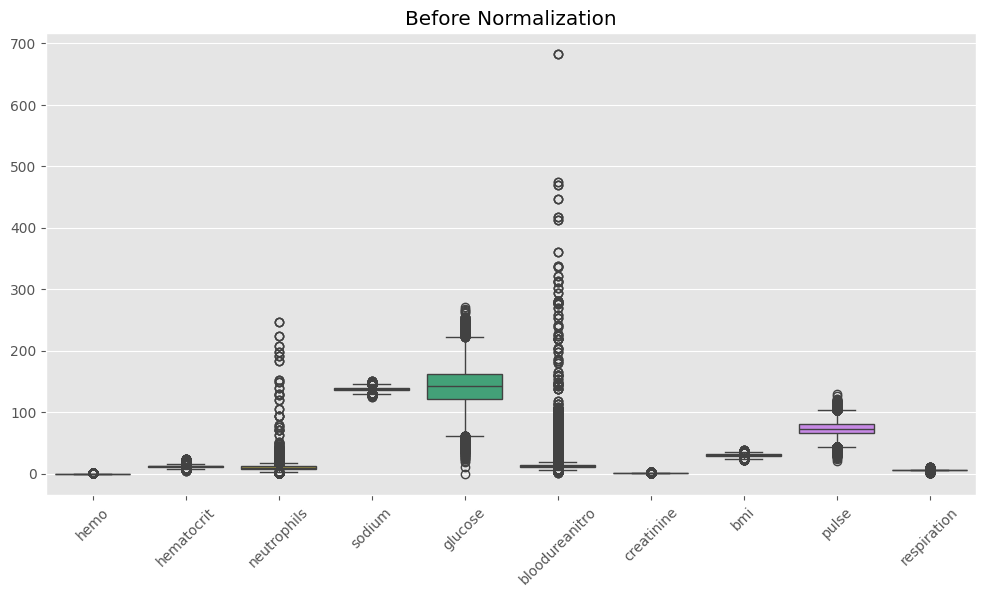

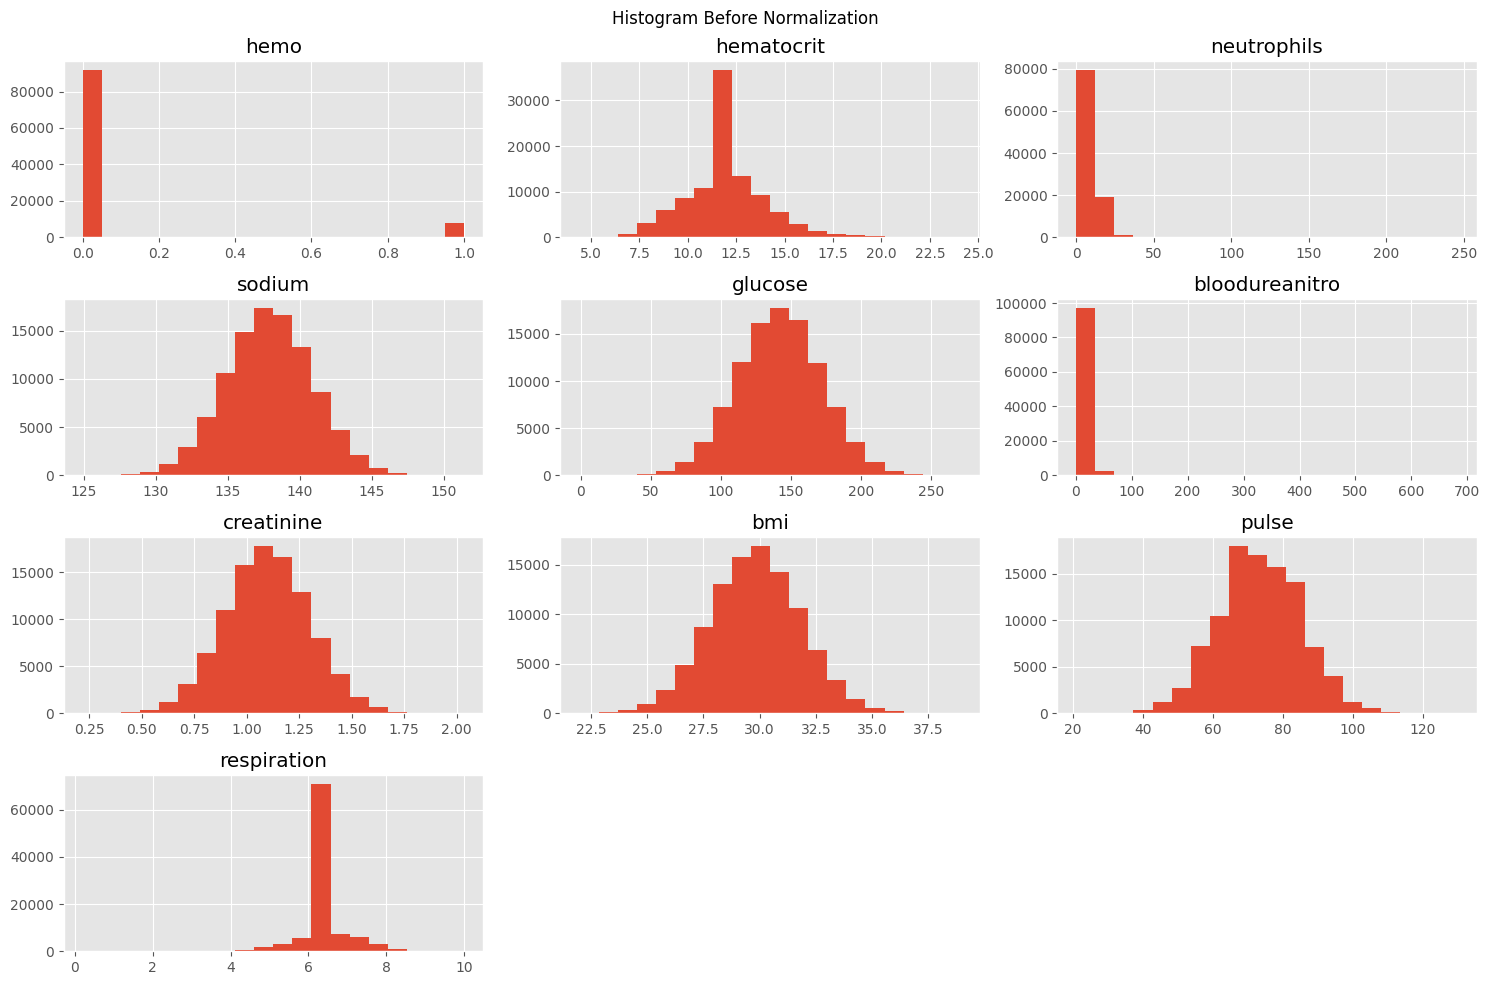

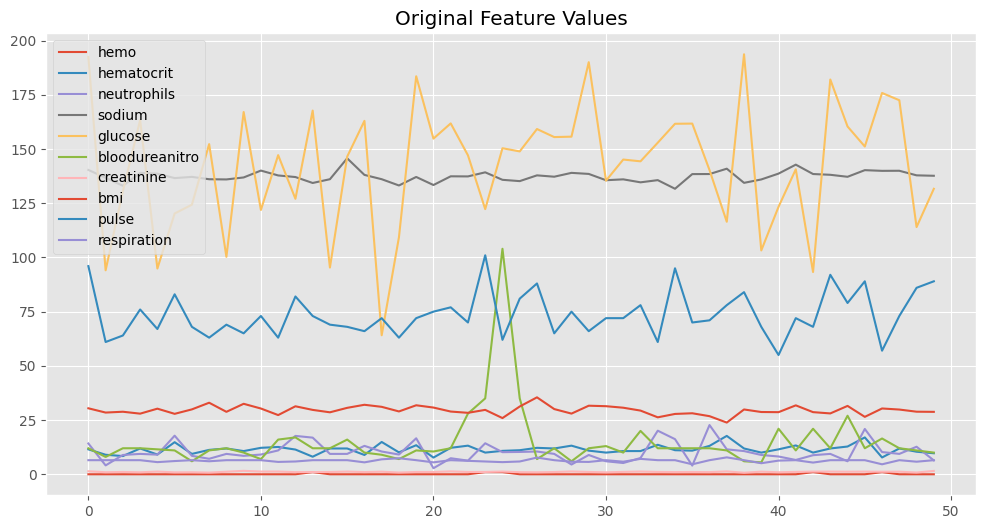


Min-Max Normalized Data


,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration
0,0.0,0.360406,0.057364,0.583520,0.710159,0.016141,0.644999,0.498137,0.688073,0.642857
1,0.0,0.233503,0.016273,0.446429,0.348997,0.010271,0.398470,0.381750,0.366972,0.642857
2,0.0,0.203046,0.035801,0.307686,0.482791,0.016141,0.465994,0.404373,0.394495,0.642857
3,0.0,0.380711,0.037836,0.531882,0.603350,0.016141,0.378473,0.352149,0.504587,0.642857
4,0.0,0.238579,0.036412,0.518315,0.351964,0.015407,0.563549,0.487897,0.422018,0.551020


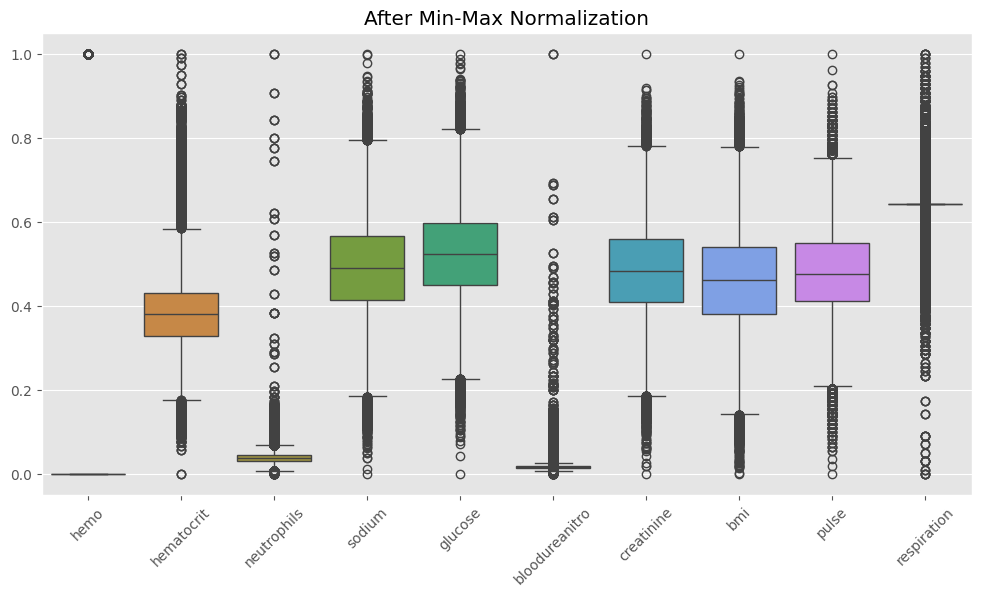

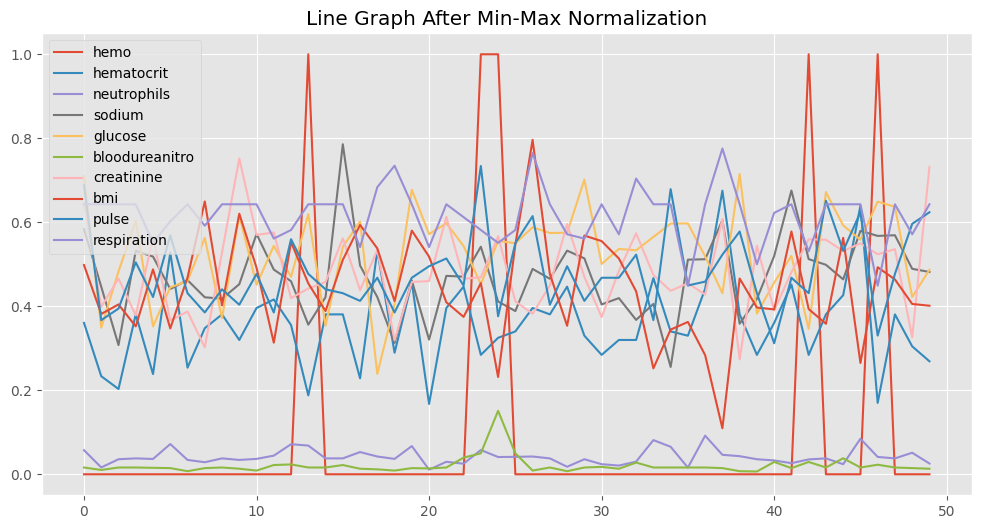


Z-Score Normalized Data


,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration
0,-0.294884,-0.234247,0.751441,0.823340,1.684186,-0.161915,1.454965,0.312741,1.936991,0.010963
1,-0.294884,-1.464694,-1.135314,-0.386613,-1.596543,-0.470738,-0.779911,-0.671360,-1.068721,0.010963
2,-0.294884,-1.760001,-0.238638,-1.611147,-0.381186,-0.161915,-0.167779,-0.480071,-0.811089,0.010963
3,-0.294884,-0.037375,-0.145235,0.367584,0.713958,-0.161915,-0.961187,-0.921644,0.219441,0.010963
4,-0.294884,-1.415476,-0.210617,0.247842,-1.569599,-0.200518,0.716587,0.226159,-0.553456,-1.572234


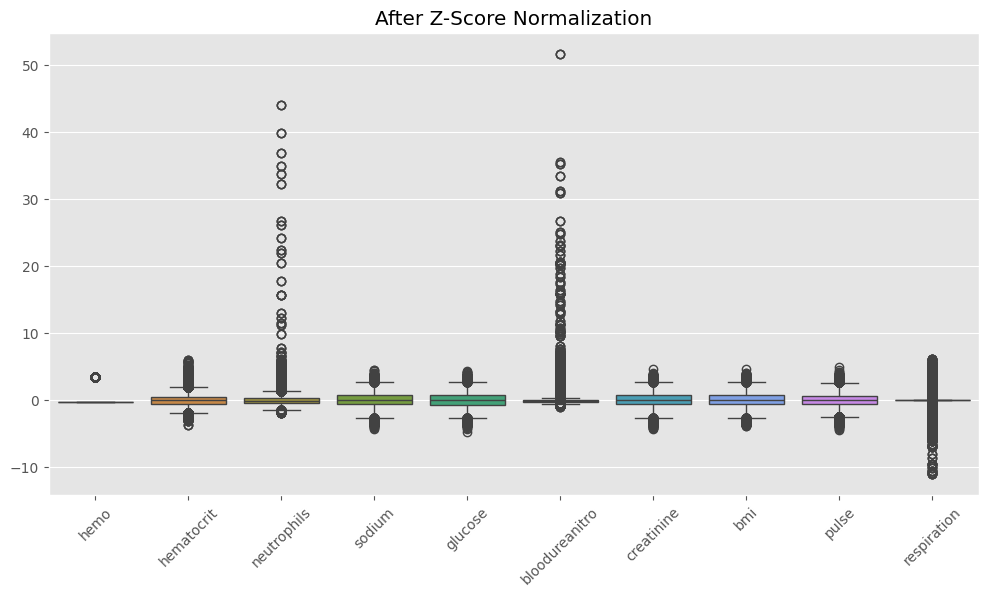

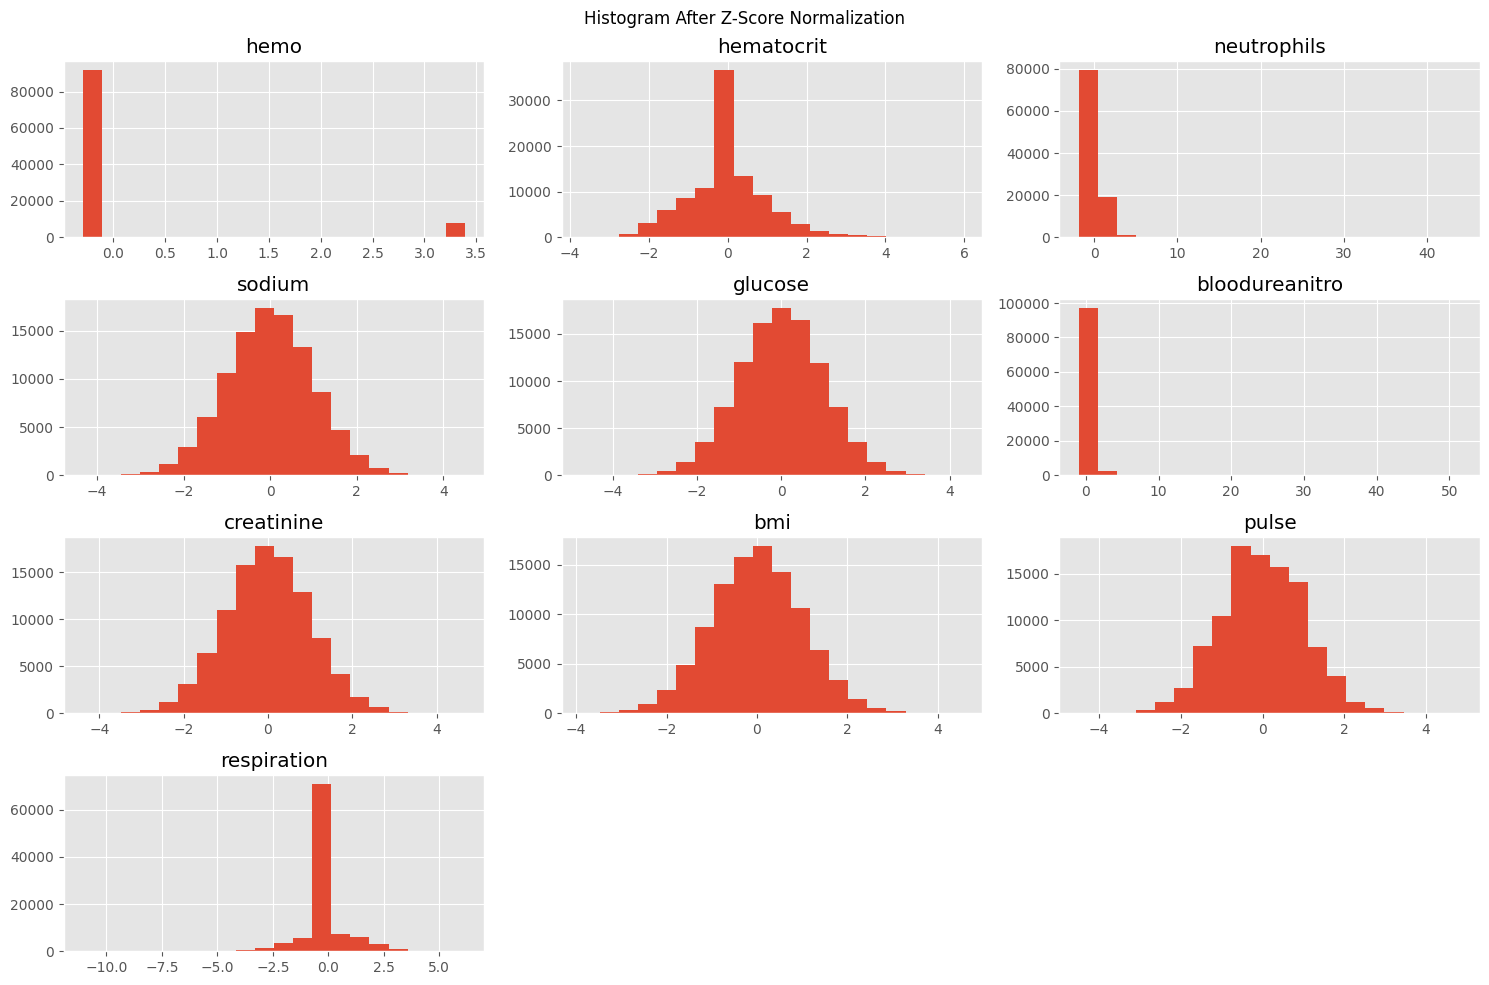

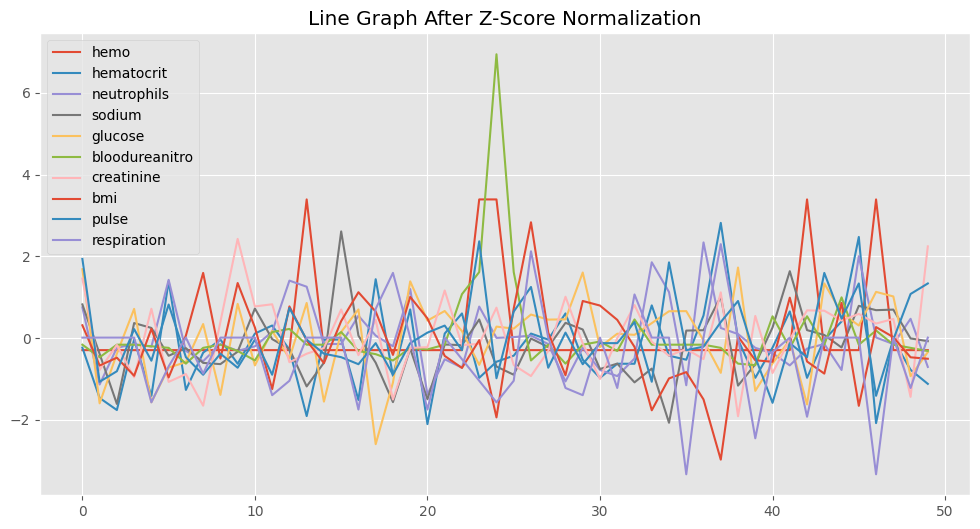


Comparison Table


,Original Mean,Min-Max Mean,Z-Score Mean
hemo,0.080000,0.080000,-4.973799e-17
hematocrit,11.975939,0.384565,-5.821477e-16
neutrophils,10.177455,0.040999,1.620037e-16
sodium,137.891397,0.490234,-6.056950e-15
glucose,141.963384,0.524754,5.812950e-16
bloodureanitro,14.097185,0.019218,-2.870593e-17
creatinine,1.099350,0.484502,9.450218e-16
bmi,29.805759,0.461150,-1.329354e-15
pulse,73.444720,0.481144,-3.281286e-16
respiration,6.493768,0.642221,2.281411e-15



Mean after Z-Score
hemo             -4.973799e-17
hematocrit       -5.821477e-16
neutrophils       1.620037e-16
sodium           -6.056950e-15
glucose           5.812950e-16
bloodureanitro   -2.870593e-17
creatinine        9.450218e-16
bmi              -1.329354e-15
pulse            -3.281286e-16
respiration       2.281411e-15
dtype: float64

Standard Deviation after Z-Score
hemo              1.000005
hematocrit        1.000005
neutrophils       1.000005
sodium            1.000005
glucose           1.000005
bloodureanitro    1.000005
creatinine        1.000005
bmi               1.000005
pulse             1.000005
respiration       1.000005
dtype: float64

CONCLUSION

1. Min-Max Normalization scales data between 0 and 1.
2. Z-Score Normalization transforms data to Mean = 0 and Standard Deviation = 1.
3. Healthcare data contains measurements with different scales.
4. Z-Score Normalization is generally more suitable for Patient Length of Stay datasets because it handles varying feature s

In [ ]:
# ============================================
# LAB EXERCISE 2
# Patient Length of Stay Prediction
# Preprocessing using Normalization Techniques
# ============================================

# -------------------------------
# Import Libraries
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.preprocessing import MinMaxScaler, StandardScaler

plt.style.use('ggplot')

# -------------------------------
# Upload Dataset
# -------------------------------

uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Read CSV
df = pd.read_csv(filename)

print("Dataset Loaded Successfully!")

# -------------------------------
# Dataset Understanding
# -------------------------------

print("\nFirst 5 Rows")
display(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nDataset Information")
df.info()

print("\nSummary Statistics")
display(df.describe())

print("\nColumn Names")
print(df.columns.tolist())

# -------------------------------
# Numerical & Categorical Columns
# -------------------------------

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

# -------------------------------
# Missing Values
# -------------------------------

print("\nMissing Values")
display(df.isnull().sum())

# Fill missing numerical values with median

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# -------------------------------
# Duplicate Records
# -------------------------------

print("\nDuplicate Records:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

# -------------------------------
# Features for Normalization
# -------------------------------

features = [
    'hemo',
    'hematocrit',
    'neutrophils',
    'sodium',
    'glucose',
    'bloodureanitro',
    'creatinine',
    'bmi',
    'pulse',
    'respiration'
]

# -------------------------------
# ORIGINAL DATA
# -------------------------------

print("\nOriginal Feature Values")
display(df[features].head())

# -------------------------------
# Box Plot Before Normalization
# -------------------------------

plt.figure(figsize=(12,6))
sns.boxplot(data=df[features])
plt.xticks(rotation=45)
plt.title("Before Normalization")
plt.show()

# -------------------------------
# Histogram Before Normalization
# -------------------------------

df[features].hist(figsize=(15,10), bins=20)
plt.suptitle("Histogram Before Normalization")
plt.tight_layout()
plt.show()

# -------------------------------
# Line Graph Before Normalization
# -------------------------------

df[features].head(50).plot(figsize=(12,6))
plt.title("Original Feature Values")
plt.show()

# -------------------------------
# Min-Max Normalization
# -------------------------------

minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(df[features])

minmax_df = pd.DataFrame(minmax_scaled, columns=features)

print("\nMin-Max Normalized Data")
display(minmax_df.head())

# -------------------------------
# Box Plot After Min-Max
# -------------------------------

plt.figure(figsize=(12,6))
sns.boxplot(data=minmax_df)
plt.xticks(rotation=45)
plt.title("After Min-Max Normalization")
plt.show()

# -------------------------------
# Line Graph After Min-Max
# -------------------------------

minmax_df.head(50).plot(figsize=(12,6))
plt.title("Line Graph After Min-Max Normalization")
plt.show()

# -------------------------------
# Z-Score Normalization
# -------------------------------

standard_scaler = StandardScaler()

zscore_scaled = standard_scaler.fit_transform(df[features])

zscore_df = pd.DataFrame(zscore_scaled, columns=features)

print("\nZ-Score Normalized Data")
display(zscore_df.head())

# -------------------------------
# Box Plot After Z-Score
# -------------------------------

plt.figure(figsize=(12,6))
sns.boxplot(data=zscore_df)
plt.xticks(rotation=45)
plt.title("After Z-Score Normalization")
plt.show()

# -------------------------------
# Histogram After Z-Score
# -------------------------------

zscore_df.hist(figsize=(15,10), bins=20)
plt.suptitle("Histogram After Z-Score Normalization")
plt.tight_layout()
plt.show()

# -------------------------------
# Line Graph After Z-Score
# -------------------------------

zscore_df.head(50).plot(figsize=(12,6))
plt.title("Line Graph After Z-Score Normalization")
plt.show()

# -------------------------------
# Compare Original and Normalized Data
# -------------------------------

comparison = pd.DataFrame({
    "Original Mean": df[features].mean(),
    "Min-Max Mean": minmax_df.mean(),
    "Z-Score Mean": zscore_df.mean()
})

print("\nComparison Table")
display(comparison)

# -------------------------------
# Check Mean & Standard Deviation
# -------------------------------

print("\nMean after Z-Score")
print(zscore_df.mean())

print("\nStandard Deviation after Z-Score")
print(zscore_df.std())

# -------------------------------
# Final Conclusion
# -------------------------------

print("""
======================================================
CONCLUSION
======================================================

1. Min-Max Normalization scales data between 0 and 1.
2. Z-Score Normalization transforms data to Mean = 0 and Standard Deviation = 1.
3. Healthcare data contains measurements with different scales.
4. Z-Score Normalization is generally more suitable for Patient Length of Stay datasets because it handles varying feature scales effectively.
5. Normalization improves the performance of many Machine Learning algorithms.

======================================================
""")